# Hypothesis Testing on Rover Telemetry

This notebook applies formal statistical hypothesis tests to evaluate whether observed differences in rover telemetry and operational behavior are statistically significant.

Three operational questions are examined using appropriate parametric or non-parametric tests, with each analysis reporting the hypotheses, test selection, test statistic, p-value, sample size, statistical conclusion, and operational implication.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
df = pd.read_csv("../Data/aido_rover_telemetry.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(
    f"Dataset shape: "
    f"{df.shape[0]:,} rows × "
    f"{df.shape[1]} columns"
)

display(df.head())

Dataset shape: 181,440 rows × 20 columns


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0


## 1. Battery SoC at FAULT Onset vs. PATROL Operation

The first hypothesis test evaluates whether battery state of charge (SoC) at the onset of a `FAULT` operating period differs from battery SoC observed during normal `PATROL` operation.

Only the first observation of each continuous FAULT episode is used to represent fault onset. This avoids treating every observation within the same fault episode as an independent fault event.

### Hypotheses

- **H₀:** The distribution of Battery SoC is the same between FAULT onset and PATROL observations.
- **H₁:** The distribution of Battery SoC differs between FAULT onset and PATROL observations.

A significance level of **α = 0.05** is used.

In [3]:
test_data = (
    df
    .sort_values(
        ["rover_id", "timestamp"]
    )
    .copy()
)

test_data["previous_mode"] = (
    test_data
    .groupby("rover_id")[
        "operational_mode"
    ]
    .shift(1)
)

test_data["fault_onset"] = (
    (test_data["operational_mode"] == "FAULT")
    &
    (test_data["previous_mode"] != "FAULT")
)

fault_onset_data = (
    test_data[
        test_data["fault_onset"]
    ]
    .copy()
)

print(
    f"FAULT onset events: "
    f"{len(fault_onset_data):,}"
)

display(
    fault_onset_data[
        [
            "rover_id",
            "timestamp",
            "battery_soc",
            "previous_mode",
            "operational_mode"
        ]
    ].head()
)

FAULT onset events: 8,497


,rover_id,timestamp,battery_soc,previous_mode,operational_mode
1,AIDO_001,2026-07-01 00:05:00,76.275079,PATROL,FAULT
11,AIDO_001,2026-07-01 00:55:00,75.686926,PATROL,FAULT
34,AIDO_001,2026-07-01 02:50:00,74.230467,CHARGING,FAULT
50,AIDO_001,2026-07-01 04:10:00,73.474427,PATROL,FAULT
69,AIDO_001,2026-07-01 05:45:00,73.988283,PATROL,FAULT


In [4]:
fault_soc = (
    fault_onset_data["battery_soc"]
    .dropna()
)

patrol_soc = (
    test_data.loc[
        test_data["operational_mode"]
        == "PATROL",
        "battery_soc"
    ]
    .dropna()
)

group_summary = pd.DataFrame({
    "Group": [
        "FAULT Onset",
        "PATROL"
    ],
    "Sample Size": [
        len(fault_soc),
        len(patrol_soc)
    ],
    "Mean SoC": [
        fault_soc.mean(),
        patrol_soc.mean()
    ],
    "Median SoC": [
        fault_soc.median(),
        patrol_soc.median()
    ],
    "Std SoC": [
        fault_soc.std(),
        patrol_soc.std()
    ]
})

display(
    group_summary.round(3)
)

,Group,Sample Size,Mean SoC,Median SoC,Std SoC
0,FAULT Onset,8497,16.193,0.557,25.994
1,PATROL,126960,16.415,0.673,26.033


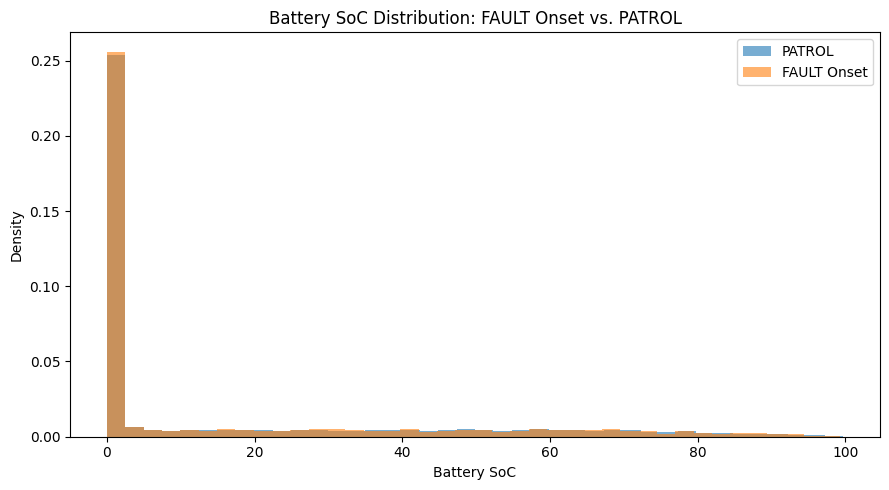

In [5]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.hist(
    patrol_soc,
    bins=40,
    alpha=0.6,
    density=True,
    label="PATROL"
)

ax.hist(
    fault_soc,
    bins=40,
    alpha=0.6,
    density=True,
    label="FAULT Onset"
)

ax.set_title(
    "Battery SoC Distribution: "
    "FAULT Onset vs. PATROL"
)

ax.set_xlabel("Battery SoC")
ax.set_ylabel("Density")

ax.legend()

plt.tight_layout()
plt.show()

### Test Selection

Battery SoC is a continuous variable, while the analysis compares two independent groups: FAULT onset observations and PATROL observations.

The Battery SoC distributions are strongly skewed, with substantial differences between the mean and median in both groups. Because the normality assumption required for an independent-samples t-test is not appropriate for these distributions, a **Mann–Whitney U test** is used as a non-parametric alternative.

The test evaluates whether the distributions of Battery SoC differ between FAULT onset and PATROL operation. A **two-sided test** is used with a significance level of **α = 0.05**.

In [21]:
u_statistic, p_mannwhitney = (
    stats.mannwhitneyu(
        fault_soc,
        patrol_soc,
        alternative="two-sided"
    )
)

print(
    f"Mann–Whitney U statistic: "
    f"{u_statistic:,.0f}"
)

print(
    f"Two-sided p-value: "
    f"{p_mannwhitney:.6g}"
)

print(
    f"FAULT onset sample size: "
    f"{len(fault_soc):,}"
)

print(
    f"PATROL sample size: "
    f"{len(patrol_soc):,}"
)

Mann–Whitney U statistic: 518,211,418
Two-sided p-value: 8.83652e-10
FAULT onset sample size: 8,497
PATROL sample size: 126,960


In [22]:
n_fault = len(fault_soc)
n_patrol = len(patrol_soc)

rank_biserial = (
    2 * u_statistic
    / (n_fault * n_patrol)
    - 1
)

print(
    f"Rank-biserial correlation: "
    f"{rank_biserial:.4f}"
)

Rank-biserial correlation: -0.0393


### Results and Interpretation

The Mann–Whitney U test identified a statistically significant difference in Battery SoC between FAULT onset and PATROL observations (U = 518,211,418, two-sided p < 0.001).

However, the rank-biserial correlation was -0.039, indicating a very small effect size. The median Battery SoC values were also similar between FAULT onset (0.557) and PATROL operation (0.673).

Therefore, the null hypothesis is rejected statistically, but the magnitude of the difference is operationally small. Battery SoC alone does not appear to provide strong separation between FAULT onset and normal PATROL observations.

**Operational implication:** Battery SoC should not be used as a standalone indicator of imminent FAULT conditions. It may be more useful when combined with other telemetry signals or changes in Battery SoC over time.

## 2. LiDAR Saturation and FAULT Occurrence

The second hypothesis test evaluates whether LiDAR saturation is associated with FAULT occurrence.

Each telemetry observation is classified by whether LiDAR saturation is present and whether the rover is operating in FAULT mode. A chi-square test of independence is used to determine whether FAULT occurrence is associated with LiDAR saturation.

### Hypotheses

- **H₀:** FAULT occurrence is independent of LiDAR saturation.
- **H₁:** FAULT occurrence is associated with LiDAR saturation.

A significance level of **α = 0.05** is used.

In [34]:
lidar_fault_data = df[
    [
        "lidar_saturation_flag",
        "operational_mode"
    ]
].copy()

lidar_fault_data["is_fault"] = (
    lidar_fault_data["operational_mode"]
    == "FAULT"
)

lidar_fault_summary = (
    lidar_fault_data
    .groupby("lidar_saturation_flag")
    .agg(
        total_observations=(
            "is_fault",
            "size"
        ),
        fault_observations=(
            "is_fault",
            "sum"
        )
    )
)

lidar_fault_summary["fault_rate"] = (
    lidar_fault_summary["fault_observations"]
    / lidar_fault_summary["total_observations"]
)

lidar_fault_summary.index = [
    "No LiDAR Saturation",
    "LiDAR Saturation"
]

display(
    lidar_fault_summary.round(4)
)

,total_observations,fault_observations,fault_rate
No LiDAR Saturation,179626,8854,0.0493
LiDAR Saturation,1814,112,0.0617


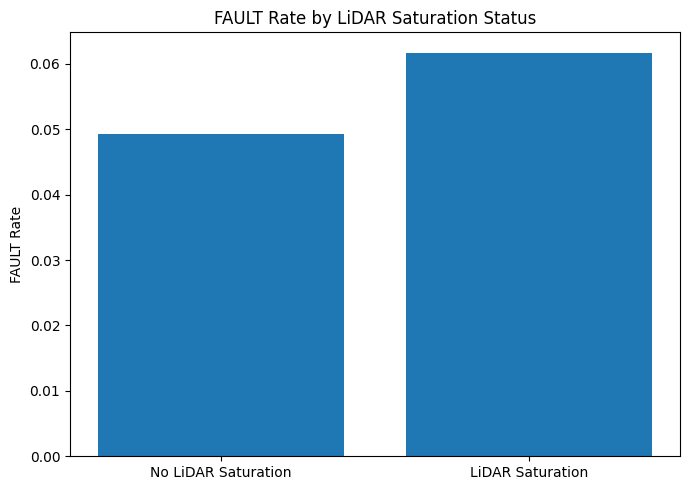

In [35]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    lidar_fault_summary.index,
    lidar_fault_summary["fault_rate"]
)

ax.set_title(
    "FAULT Rate by LiDAR Saturation Status"
)

ax.set_ylabel("FAULT Rate")

plt.tight_layout()
plt.show()

In [36]:
lidar_fault_table = pd.crosstab(
    lidar_fault_data[
        "lidar_saturation_flag"
    ],
    lidar_fault_data[
        "is_fault"
    ]
)

lidar_fault_table.columns = [
    "Non-FAULT",
    "FAULT"
]

lidar_fault_table.index = [
    "No LiDAR Saturation",
    "LiDAR Saturation"
]

display(
    lidar_fault_table
)

,Non-FAULT,FAULT
No LiDAR Saturation,170772,8854
LiDAR Saturation,1702,112


### Test Selection

Both LiDAR saturation status and FAULT occurrence are categorical variables. A **chi-square test of independence** is therefore used to evaluate whether the two variables are associated.

The expected cell counts are sufficiently large for the chi-square approximation, with a minimum expected count greater than 5.

A significance level of **α = 0.05** is used.

In [40]:
chi2_lidar, p_lidar, dof_lidar, expected_lidar = (
    stats.chi2_contingency(
        lidar_fault_table
    )
)

print(
    f"Chi-square statistic: "
    f"{chi2_lidar:.3f}"
)

print(
    f"Degrees of freedom: "
    f"{dof_lidar}"
)

print(
    f"p-value: "
    f"{p_lidar:.6g}"
)

print(
    f"Sample size: "
    f"{n_lidar:,}"
)

print(
    f"Minimum expected count: "
    f"{expected_lidar.min():.2f}"
)


Chi-square statistic: 5.664
Degrees of freedom: 1
p-value: 0.0173117
Sample size: 181,440
Minimum expected count: 89.64


In [41]:
n_lidar = (
    lidar_fault_table
    .to_numpy()
    .sum()
)

cramers_v_lidar = np.sqrt(
    chi2_lidar / n_lidar
)

print(
    f"Cramér's V: "
    f"{cramers_v_lidar:.4f}"
)

Cramér's V: 0.0056


### Results and Interpretation

The chi-square test identified a statistically significant association between LiDAR saturation and FAULT occurrence (χ²(1) = 5.664, p = 0.017, n = 181,440).

FAULT observations accounted for approximately 4.93% of observations without LiDAR saturation and 6.17% of observations with LiDAR saturation. However, Cramér's V was 0.006, indicating that the strength of the association was negligible.

Therefore, the null hypothesis is rejected statistically, but the magnitude of the association is operationally small. LiDAR saturation is associated with a slightly higher FAULT rate, but it does not provide strong separation between FAULT and non-FAULT conditions on its own.

**Operational implication:** LiDAR saturation may provide a weak supplementary signal for identifying elevated FAULT risk, but it should not be used as a standalone fault indicator. Combining LiDAR status with other telemetry and sensor-health signals would likely provide more useful operational monitoring.

## 3. FAULT Occurrence Across Rover Units

The third hypothesis test evaluates whether FAULT occurrence differs across individual rover units.

Each telemetry observation is classified as either FAULT or non-FAULT and grouped by rover ID. A chi-square test of independence is used to determine whether FAULT occurrence is associated with the individual rover unit.

### Hypotheses

- **H₀:** FAULT occurrence is independent of rover unit.
- **H₁:** FAULT occurrence is associated with rover unit.

A significance level of **α = 0.05** is used.

In [13]:
fault_data = df.copy()

fault_data["is_fault"] = (
    fault_data["operational_mode"]
    == "FAULT"
)

rover_fault_summary = (
    fault_data
    .groupby("rover_id")
    .agg(
        total_observations=(
            "is_fault",
            "size"
        ),
        fault_observations=(
            "is_fault",
            "sum"
        )
    )
)

rover_fault_summary["fault_rate"] = (
    rover_fault_summary["fault_observations"]
    / rover_fault_summary["total_observations"]
)

display(
    rover_fault_summary.round(4)
)

,total_observations,fault_observations,fault_rate
rover_id,,,
AIDO_001,6048,318,0.0526
AIDO_002,6048,254,0.0420
AIDO_003,6048,315,0.0521
AIDO_004,6048,344,0.0569
AIDO_005,6048,273,0.0451
AIDO_006,6048,303,0.0501
AIDO_007,6048,301,0.0498
AIDO_008,6048,298,0.0493
AIDO_009,6048,284,0.0470


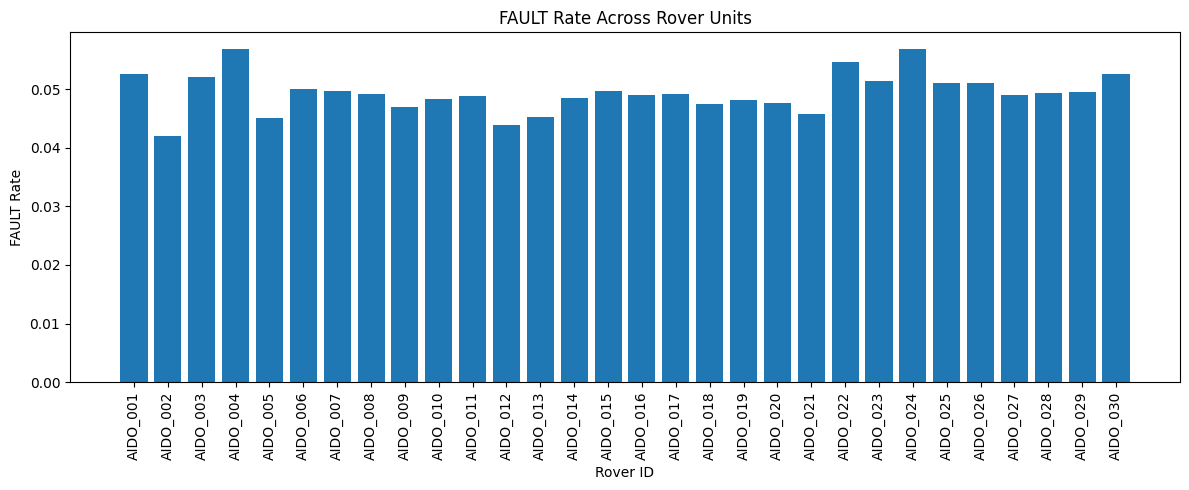

In [14]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.bar(
    rover_fault_summary.index,
    rover_fault_summary["fault_rate"]
)

ax.set_title(
    "FAULT Rate Across Rover Units"
)

ax.set_xlabel("Rover ID")
ax.set_ylabel("FAULT Rate")

ax.tick_params(
    axis="x",
    rotation=90
)

plt.tight_layout()
plt.show()

### Test Selection

Rover identity and FAULT occurrence are both categorical variables. A **chi-square test of independence** is therefore used to evaluate whether FAULT occurrence is associated with the individual rover unit.

Each rover has the same number of telemetry observations, allowing FAULT observation rates to be compared across units under equal observation exposure. The expected cell counts are sufficiently large for the chi-square approximation, with a minimum expected count greater than 5.

A significance level of **α = 0.05** is used.

In [15]:
fault_contingency = pd.crosstab(
    fault_data["rover_id"],
    fault_data["is_fault"]
)

fault_contingency.columns = [
    "Non-FAULT",
    "FAULT"
]

display(fault_contingency)

,Non-FAULT,FAULT
rover_id,,
AIDO_001,5730,318
AIDO_002,5794,254
AIDO_003,5733,315
AIDO_004,5704,344
AIDO_005,5775,273
AIDO_006,5745,303
AIDO_007,5747,301
AIDO_008,5750,298
AIDO_009,5764,284


In [19]:
chi2_fault, p_fault, dof_fault, expected_fault = (
    stats.chi2_contingency(
        fault_contingency
    )
)

print(
    f"Chi-square statistic: "
    f"{chi2_fault:.3f}"
)

print(
    f"Degrees of freedom: "
    f"{dof_fault}"
)

print(
    f"p-value: "
    f"{p_fault:.6g}"
)

print(
    f"Sample size: "
    f"{len(fault_data):,}"
)

print(
    f"Minimum expected count: "
    f"{expected_fault.min():.2f}"
)

Chi-square statistic: 42.202
Degrees of freedom: 29
p-value: 0.0538549
Sample size: 181,440
Minimum expected count: 298.87


In [17]:
n_fault_total = (
    fault_contingency
    .to_numpy()
    .sum()
)

cramers_v_fault = np.sqrt(
    chi2_fault
    / (
        n_fault_total
        * min(
            fault_contingency.shape[0] - 1,
            fault_contingency.shape[1] - 1
        )
    )
)

print(
    f"Cramér's V: "
    f"{cramers_v_fault:.4f}"
)

Cramér's V: 0.0153


In [18]:
fault_rate_ranking = (
    rover_fault_summary
    .sort_values(
        "fault_rate",
        ascending=False
    )
)

print("Highest FAULT Rates")
display(
    fault_rate_ranking.head(5).round(4)
)

print("Lowest FAULT Rates")
display(
    fault_rate_ranking.tail(5).round(4)
)

Highest FAULT Rates


,total_observations,fault_observations,fault_rate
rover_id,,,
AIDO_024,6048,344,0.0569
AIDO_004,6048,344,0.0569
AIDO_022,6048,331,0.0547
AIDO_001,6048,318,0.0526
AIDO_030,6048,318,0.0526


Lowest FAULT Rates


,total_observations,fault_observations,fault_rate
rover_id,,,
AIDO_021,6048,277,0.0458
AIDO_013,6048,274,0.0453
AIDO_005,6048,273,0.0451
AIDO_012,6048,266,0.0440
AIDO_002,6048,254,0.0420


### Results and Interpretation

The chi-square test did not identify a statistically significant association between rover unit and FAULT occurrence at the α = 0.05 significance level (χ²(29) = 42.202, p = 0.054, n = 181,440).

The minimum expected cell count was 298.87, indicating that the expected-frequency assumption for the chi-square test was satisfied. Cramér's V was 0.015, indicating a negligible association between rover identity and FAULT occurrence.

Observed FAULT rates ranged from 4.20% for AIDO_002 to 5.69% for AIDO_004 and AIDO_024. Although some rover units showed higher observed FAULT rates than others, these differences were not statistically significant at the predefined α = 0.05 level.

Therefore, the null hypothesis is not rejected. The telemetry does not provide sufficient evidence that FAULT occurrence systematically differs across rover units.

**Operational implication:** Rover identity alone does not appear to be a strong indicator of FAULT occurrence. Maintenance and monitoring decisions should rely on telemetry conditions and fault-related sensor behavior rather than assuming that specific rover units are inherently more fault-prone.

## Summary Table

In [42]:
hypothesis_summary = pd.DataFrame({
    "Test": [
        "Battery SoC: FAULT Onset vs. PATROL",
        "LiDAR Saturation vs. FAULT Occurrence",
        "FAULT Rate by Rover"
    ],

    "Method": [
        "Mann–Whitney U",
        "Chi-square",
        "Chi-square"
    ],

    "p-value": [
        f"{p_mannwhitney:.3e}",
        f"{p_lidar:.4f}",
        f"{p_fault:.4f}"
    ],

    "Effect Size": [
        f"{abs(rank_biserial):.4f}",
        f"{cramers_v_lidar:.4f}",
        f"{cramers_v_fault:.4f}"
    ],

    "Decision": [
        "Reject H0",
        "Reject H0",
        "Fail to Reject H0"
    ]
})

display(hypothesis_summary)

,Test,Method,p-value,Effect Size,Decision
0,Battery SoC: FAULT Onset vs. PATROL,Mann–Whitney U,8.837e-10,0.0393,Reject H0
1,LiDAR Saturation vs. FAULT Occurrence,Chi-square,0.0173,0.0056,Reject H0
2,FAULT Rate by Rover,Chi-square,0.0539,0.0153,Fail to Reject H0


## Key Findings and Operational Implications

Three formal hypothesis tests were conducted to evaluate relationships between battery condition, sensor anomalies, and operational FAULT behavior.

1. **Battery SoC at FAULT onset vs. PATROL:** Battery SoC differed significantly between FAULT onset and PATROL observations (p < 0.001). However, the rank-biserial correlation was very small, indicating that Battery SoC alone provides limited separation between the two operating conditions.

2. **LiDAR saturation and FAULT occurrence:** A statistically significant association was found between LiDAR saturation and FAULT occurrence (p = 0.017). The FAULT rate increased from approximately 4.93% without LiDAR saturation to 6.17% with saturation, but the very small Cramér's V indicated that the association was operationally weak.

3. **FAULT rate across rover units:** No statistically significant association was found between rover identity and FAULT occurrence at the α = 0.05 level (p = 0.054). Although observed FAULT rates varied across individual rovers, the effect size was negligible.

Overall, the results show that statistical significance does not necessarily imply strong operational importance. Battery SoC and LiDAR saturation showed statistically detectable relationships with FAULT behavior, but both effects were small, while rover identity showed no significant association. These findings suggest that reliable FAULT monitoring should combine multiple telemetry and sensor-health signals rather than relying on any single variable or rover-specific assumption.

## Limitations

This analysis is based on synthetic rover telemetry, so the observed statistical relationships reflect the assumptions and patterns embedded in the simulated dataset and may not fully represent real-world rover operations.

The telemetry contains repeated observations from the same rover at five-minute intervals. These observations may be temporally correlated, while the statistical tests used here assume independent observations. Future analysis could account for repeated measurements and rover-level temporal dependence using more advanced statistical methods.

In addition, the FAULT analysis uses observation-level FAULT status rather than independent FAULT episodes. Longer FAULT periods therefore contribute more observations to the analysis than shorter events.

Finally, statistical significance should be interpreted together with effect size. Although Battery SoC and LiDAR saturation produced statistically significant results, their effect sizes were very small, indicating limited operational importance when considered individually.